# NLP Assignment - Simple PDF Text Processing
Machine Learning by Tom Mitchell

## Import Libraries

In [1]:
import re
import pandas as pd
from pypdf import PdfReader
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Q1(a): PDF Reading and Text Extraction

In [3]:
# PDF file path
pdf_path = r'd:\BS AI\Semester 06\NLP\Lab\Assignments\Assignment 02\MachineLearningTomMitchell.pdf'

# Read PDF file
pdf_reader = PdfReader(pdf_path)

# Get total pages
total_pages = len(pdf_reader.pages)
print(f"Total Pages in PDF: {total_pages}")

# Number of pages to extract
pages_to_extract = min(150, total_pages)
print(f"Pages to Extract: {pages_to_extract}")

Total Pages in PDF: 421
Pages to Extract: 150


In [5]:
# Extract text from first 120 pages
extracted_text = ""

for page_num in range(pages_to_extract):
    page = pdf_reader.pages[page_num]
    extracted_text += page.extract_text()

print(f"Extraction Complete!")
print(f"Total characters extracted: {len(extracted_text)}")

Extraction Complete!
Total characters extracted: 369131


In [6]:
# Display sample extracted text
print("Sample Extracted Text (first 500 characters):")
print("=" * 80)
print(extracted_text[:500])
print("=" * 80)

Sample Extracted Text (first 500 characters):
 
 
Machine Learning  
Tom M. Mitchell 
 
 
Product Details  
• Hardcover: 432 pages ; Dimensions (in inches): 0.75 x 10.00 x 6.50  
• Publisher: McGraw-Hill Science/Engineering/Math; (March 1, 1997)  
• ISBN: 0070428077  
• Average Customer Review: 
 Based on 16 reviews. 
• Amazon.com Sales Rank: 42,816  
• Popular in: Redmond, WA (#17) , Ithaca, NY (#9)  
 
 
Editorial Reviews 
From Book News, Inc. An introductory text on primary approaches to machine learning and 
the study of computer algori


---
# Q1(b): Text Preprocessing

In [9]:
# Step 1: Convert to lowercase
print("Step 1: Converting to lowercase...")
text = extracted_text.lower()
print("✓ Done")
print(f"Sample Text after Lowercasing (first 500 characters):")
print("=" * 80)
print(text[:500])
print("=" * 80)

Step 1: Converting to lowercase...
✓ Done
Sample Text after Lowercasing (first 500 characters):
 
 
machine learning  
tom m. mitchell 
 
 
product details  
• hardcover: 432 pages ; dimensions (in inches): 0.75 x 10.00 x 6.50  
• publisher: mcgraw-hill science/engineering/math; (march 1, 1997)  
• isbn: 0070428077  
• average customer review: 
 based on 16 reviews. 
• amazon.com sales rank: 42,816  
• popular in: redmond, wa (#17) , ithaca, ny (#9)  
 
 
editorial reviews 
from book news, inc. an introductory text on primary approaches to machine learning and 
the study of computer algori


In [10]:
# Step 2: Remove numbers using Regex
print("\nStep 2: Removing numbers using Regex...")
pattern_numbers = r'\\d+'  # Matches digits
print(f"Regex Pattern: {pattern_numbers}")
text = re.sub(r'\d+', '', text)
print("✓ Numbers removed")


Step 2: Removing numbers using Regex...
Regex Pattern: \\d+
✓ Numbers removed


In [11]:
# Step 3: Remove special symbols using Regex
print("\nStep 3: Removing special symbols using Regex...")
pattern_special = r'[^a-zA-Z\\s]'  # Keep only letters and spaces
print(f"Regex Pattern: {pattern_special}")
text = re.sub(r'[^a-zA-Z\s]', '', text)
print("✓ Special symbols removed")


Step 3: Removing special symbols using Regex...
Regex Pattern: [^a-zA-Z\\s]
✓ Special symbols removed


In [12]:
# Step 4: Remove extra spaces using Regex
print("\nStep 4: Removing extra spaces using Regex...")
pattern_spaces = r'\\s+'  # Matches multiple spaces
print(f"Regex Pattern: {pattern_spaces}")
text = re.sub(r'\s+', ' ', text).strip()
print("✓ Extra spaces removed")


Step 4: Removing extra spaces using Regex...
Regex Pattern: \\s+
✓ Extra spaces removed


In [13]:
# Step 5: Tokenize text into words
print("\nStep 5: Tokenizing text into words...")
words = text.split()
print(f"✓ Total words: {len(words)}")
print(f"First 20 words: {words[:20]}")


Step 5: Tokenizing text into words...
✓ Total words: 56185
First 20 words: ['machine', 'learning', 'tom', 'm', 'mitchell', 'product', 'details', 'hardcover', 'pages', 'dimensions', 'in', 'inches', 'x', 'x', 'publisher', 'mcgrawhill', 'scienceengineeringmath', 'march', 'isbn', 'average']


In [14]:
# Step 6: Remove stop words
print("\nStep 6: Removing stop words...")
stop_words = set(stopwords.words('english'))

# Count stop words
stop_words_count = sum(1 for word in words if word in stop_words)
print(f"Stop words found: {stop_words_count}")

# Remove stop words
clean_words = [w for w in words if w not in stop_words and len(w) > 2]
print(f"Valid words after removing stop words: {len(clean_words)}")
print(f"First 20 valid words: {clean_words[:20]}")


Step 6: Removing stop words...
Stop words found: 23055
Valid words after removing stop words: 31056
First 20 valid words: ['machine', 'learning', 'tom', 'mitchell', 'product', 'details', 'hardcover', 'pages', 'dimensions', 'inches', 'publisher', 'mcgrawhill', 'scienceengineeringmath', 'march', 'isbn', 'average', 'customer', 'review', 'based', 'reviews']


In [15]:
# Step 7: Apply Stemming
print("\nStep 7: Applying Stemming...")
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in clean_words]

print("Examples of stemming (word → stem):")
for i in range(15):
    print(f"  {clean_words[i]} → {stemmed_words[i]}")


Step 7: Applying Stemming...
Examples of stemming (word → stem):
  machine → machin
  learning → learn
  tom → tom
  mitchell → mitchel
  product → product
  details → detail
  hardcover → hardcov
  pages → page
  dimensions → dimens
  inches → inch
  publisher → publish
  mcgrawhill → mcgrawhil
  scienceengineeringmath → scienceengineeringmath
  march → march
  isbn → isbn


In [16]:
# Step 8: Apply Lemmatization
print("\nStep 8: Applying Lemmatization...")
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in clean_words]

print("Examples of lemmatization (word → lemma):")
for i in range(15):
    print(f"  {clean_words[i]} → {lemmatized_words[i]}")


Step 8: Applying Lemmatization...
Examples of lemmatization (word → lemma):
  machine → machine
  learning → learning
  tom → tom
  mitchell → mitchell
  product → product
  details → detail
  hardcover → hardcover
  pages → page
  dimensions → dimension
  inches → inch
  publisher → publisher
  mcgrawhill → mcgrawhill
  scienceengineeringmath → scienceengineeringmath
  march → march
  isbn → isbn


In [17]:
# Summary of preprocessing
print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)
print(f"Original words: {len(words)}")
print(f"Stop words found: {stop_words_count}")
print(f"Valid words (after stop word removal): {len(clean_words)}")
print("="*70)


PREPROCESSING SUMMARY
Original words: 56185
Stop words found: 23055
Valid words (after stop word removal): 31056


---
# Q1(c): Feature Extraction

In [18]:
# Feature Extraction 1: One Hot Encoding
print("Feature Extraction 1: ONE HOT ENCODING")
print("="*70)

# Get unique words (first 30 for simple display)
unique_words = sorted(list(set(clean_words[:500])))[:30]
print(f"Unique words selected: {len(unique_words)}")
print(f"Words: {unique_words}")

Feature Extraction 1: ONE HOT ENCODING
Unique words selected: 30
Words: ['absence', 'accessible', 'acknowledgments', 'advanced', 'advances', 'algo', 'algorithms', 'allow', 'along', 'amazoncom', 'analysis', 'analyzing', 'andrew', 'applications', 'approaches', 'appropri', 'appropriate', 'areas', 'arises', 'artificial', 'assisted', 'assumed', 'assumptions', 'ate', 'attempts', 'automatically', 'autonomous', 'available', 'average', 'avrim']


In [19]:
# Create One Hot Encoding for first 10 sentences
# Split text into chunks of 50 words each
chunk_size = 50
chunks = []
for i in range(0, len(clean_words), chunk_size):
    chunk = ' '.join(clean_words[i:i+chunk_size])
    chunks.append(chunk)

print(f"Created {len(chunks)} chunks of {chunk_size} words")

# Create One Hot Encoding matrix
ohe_data = []
for chunk in chunks[:5]:  # First 5 chunks
    row = [1 if word in chunk else 0 for word in unique_words]
    ohe_data.append(row)

# Create DataFrame
ohe_df = pd.DataFrame(ohe_data, columns=unique_words)
print("\nOne Hot Encoding Table (First 5 chunks):")
print(ohe_df)

Created 622 chunks of 50 words

One Hot Encoding Table (First 5 chunks):
   absence  accessible  acknowledgments  advanced  advances  algo  algorithms  \
0        0           0                0         0         0     1           1   
1        0           0                0         1         0     1           1   
2        0           0                0         0         0     1           1   
3        0           0                0         0         1     1           1   
4        1           0                0         0         0     1           1   

   allow  along  amazoncom  ...  assisted  assumed  assumptions  ate  \
0      0      0          1  ...         0        0            0    0   
1      0      0          0  ...         0        1            0    1   
2      1      0          0  ...         0        0            0    1   
3      0      0          0  ...         0        0            0    0   
4      0      0          0  ...         0        0            1    0   

   atte

In [20]:
# Feature Extraction 2: TF-IDF
print("\n" + "="*70)
print("Feature Extraction 2: TF-IDF")
print("="*70)

# Prepare text as document
documents = chunks[:20]  # Use first 20 chunks as documents

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names
feature_names = vectorizer.get_feature_names_out()
print(f"\nTF-IDF Feature Names (top 20 words):")
print(list(feature_names))


Feature Extraction 2: TF-IDF

TF-IDF Feature Names (top 20 words):
['algorithms', 'book', 'computer', 'computers', 'concepts', 'data', 'field', 'learn', 'learning', 'like', 'machine', 'many', 'online', 'statistics', 'students', 'thank', 'theory', 'tom', 'understanding', 'would']


In [21]:
# Convert to DataFrame for better display
tfidf_dense = tfidf_matrix.toarray()

# Average TF-IDF for each word
avg_tfidf = tfidf_dense.mean(axis=0)

tfidf_df = pd.DataFrame({
    'Word': feature_names,
    'TF-IDF Score': avg_tfidf
}).sort_values('TF-IDF Score', ascending=False)

print("\nTF-IDF Values (Top Words by Average Score):")
print(tfidf_df.to_string(index=False))


TF-IDF Values (Top Words by Average Score):
         Word  TF-IDF Score
     learning      0.261404
         book      0.184197
      machine      0.178663
   algorithms      0.144933
        learn      0.124183
         many      0.117351
        thank      0.114390
        would      0.111160
     computer      0.107318
         data      0.102171
       theory      0.101931
         like      0.095056
        field      0.091277
   statistics      0.090968
     students      0.090114
          tom      0.086987
    computers      0.072957
       online      0.064312
understanding      0.063265
     concepts      0.059825


---
# Q1(d): TF-IDF Scatter Plot Using Matplotlib

Creating TF-IDF Scatter Plot...


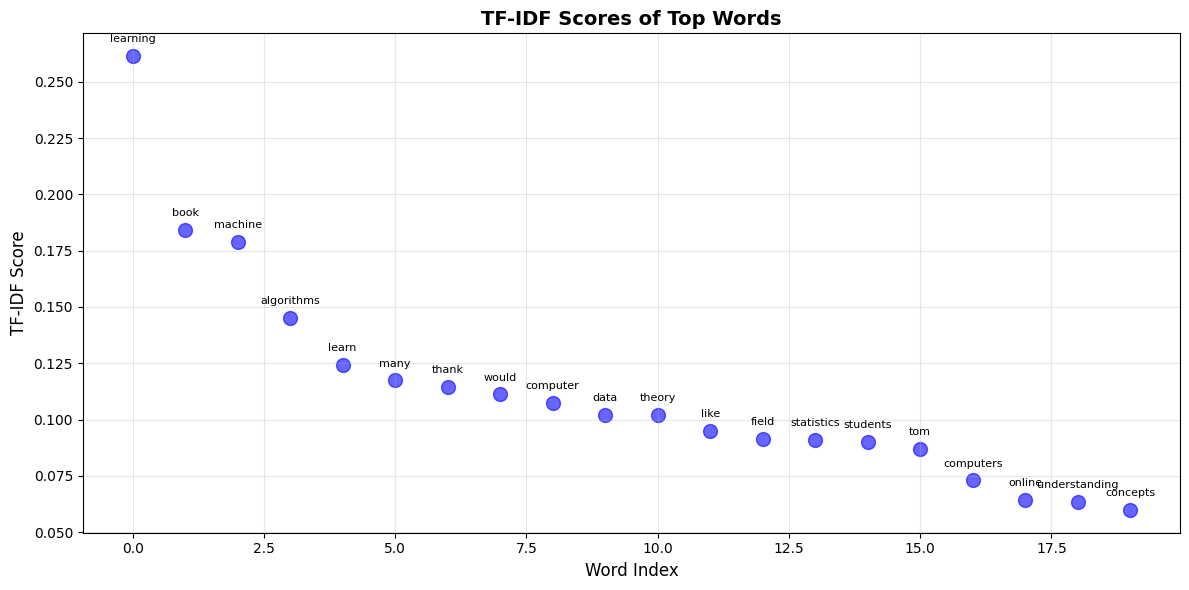

✓ Scatter plot saved as 'tfidf_scatter_plot.png'


In [22]:
# Create simple scatter plot with matplotlib
print("Creating TF-IDF Scatter Plot...")

plt.figure(figsize=(12, 6))

# Create scatter plot
plt.scatter(range(len(tfidf_df)), tfidf_df['TF-IDF Score'], 
            s=100, alpha=0.6, color='blue')

# Add word labels
for i, word in enumerate(tfidf_df['Word']):
    plt.annotate(word, 
                (i, tfidf_df['TF-IDF Score'].iloc[i]),
                textcoords="offset points", 
                xytext=(0,10),
                ha='center',
                fontsize=8)

# Labels and title
plt.xlabel('Word Index', fontsize=12)
plt.ylabel('TF-IDF Score', fontsize=12)
plt.title('TF-IDF Scores of Top Words', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('tfidf_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot saved as 'tfidf_scatter_plot.png'")

## Summary

In [23]:
print("\n" + "="*70)
print("ASSIGNMENT COMPLETION SUMMARY")
print("="*70)

print("\n✓ Q1(a): PDF READING")
print(f"  - Total Pages: {total_pages}")
print(f"  - Pages Extracted: {pages_to_extract}")
print(f"  - Characters: {len(extracted_text)}")

print("\n✓ Q1(b): TEXT PREPROCESSING")
print(f"  - Lowercase: Applied")
print(f"  - Numbers Removed (Regex: r'\\d+'): Applied")
print(f"  - Special Symbols Removed (Regex: r'[^a-zA-Z\\s]'): Applied")
print(f"  - Extra Spaces Removed (Regex: r'\\s+'): Applied")
print(f"  - Tokenization: {len(words)} words")
print(f"  - Stop Words Removed: {stop_words_count} words removed")
print(f"  - Valid Words: {len(clean_words)}")
print(f"  - Stemming: Applied")
print(f"  - Lemmatization: Applied")

print("\n✓ Q1(c): FEATURE EXTRACTION")
print(f"  - One Hot Encoding: {ohe_df.shape[0]} chunks × {ohe_df.shape[1]} words")
print(f"  - TF-IDF: {tfidf_dense.shape[0]} documents × {len(feature_names)} features")

print("\n✓ Q1(d): VISUALIZATION")
print(f"  - Scatter plot created and saved")
print(f"  - File: tfidf_scatter_plot.png")

print("\n" + "="*70)
print("✓ ALL TASKS COMPLETED!")
print("="*70)


ASSIGNMENT COMPLETION SUMMARY

✓ Q1(a): PDF READING
  - Total Pages: 421
  - Pages Extracted: 150
  - Characters: 369131

✓ Q1(b): TEXT PREPROCESSING
  - Lowercase: Applied
  - Numbers Removed (Regex: r'\d+'): Applied
  - Special Symbols Removed (Regex: r'[^a-zA-Z\s]'): Applied
  - Extra Spaces Removed (Regex: r'\s+'): Applied
  - Tokenization: 56185 words
  - Stop Words Removed: 23055 words removed
  - Valid Words: 31056
  - Stemming: Applied
  - Lemmatization: Applied

✓ Q1(c): FEATURE EXTRACTION
  - One Hot Encoding: 5 chunks × 30 words
  - TF-IDF: 20 documents × 20 features

✓ Q1(d): VISUALIZATION
  - Scatter plot created and saved
  - File: tfidf_scatter_plot.png

✓ ALL TASKS COMPLETED!
